<a href="https://colab.research.google.com/github/ksenia-andreeva/kan-physics-recovery/blob/main/kan_vs_mlp_sp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практика: Восстановление физического закона из данных**

Задача: сгенерировать данные затухающего гармонического осциллятора и восстановить закон движения.

# **Установка библиотек**

In [ ]:
!pip install git+https://github.com/KindXiaoming/pykan.git

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.integrate import solve_ivp
from kan import KAN
from kan.utils import ex_round

torch.set_default_dtype(torch.float32)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Работает на устройстве: {device}")

  Cloning https://github.com/KindXiaoming/pykan.git to /tmp/pip-req-build-5xc8i1qf
  Running command git clone --filter=blob:none --quiet https://github.com/KindXiaoming/pykan.git /tmp/pip-req-build-5xc8i1qf
  Resolved https://github.com/KindXiaoming/pykan.git to commit ecde4ec3274d3bef1ad737479cf126aed38ab530
  Preparing metadata (setup.py) ... done
Работает на устройстве: cpu


# **Обучение KAN**

In [ ]:
def rhs(t, y):
    x, v = y
    a = -(k/m)*x - (c/m)*v
    return [v, a]

all_data = []
for k in [2.0, 4.0, 6.0]:
    for c in [0.1, 0.3, 0.5]:
        for m in [0.5, 1.0, 2.0]:
            for x0 in [0, 0.5, 1.0, -0.5, -1.0]:
                for v0 in [0.0, 0.5, 1.0]:
                    sol = solve_ivp(rhs, (0, 20), y0=[x0, v0],
                                    t_eval=np.linspace(0, 10, 100))
                    x, v = sol.y
                    a = -(k/m)*x - (c/m)*v
                    for i in range(len(x)):
                        all_data.append([
                            x[i], v[i], k, c, m,
                            k/m, c/m,
                            k*x[i], c*v[i],
                            (k/m)*x[i], (c/m)*v[i],
                            a[i]
                        ])

all_data = np.array(all_data)
print(f"Всего точек: {len(all_data)}")

# Столбцы: x(0), v(1), k(2), c(3), m(4), k/m(5), c/m(6), kx(7), cv(8), kx/m(9), cv/m(10), a(11)
X = all_data[:, :11]
y = all_data[:, 11]

# Разбиение
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Масштабируем ТОЛЬКО x и v (столбцы 0 и 1), остальное не трогаем
scaler = StandardScaler()
scaler.fit(X_train[:, :2])          # обучаем только на x,v
X_train[:, :2] = scaler.transform(X_train[:, :2])
X_test[:, :2]  = scaler.transform(X_test[:, :2])

# Подвыборки (можно оставить полные данные, если скорость позволяет)
n_train = 10000
n_test  = 3000
idx_train = np.random.choice(len(X_train), n_train, replace=False)
idx_test  = np.random.choice(len(X_test),  n_test,  replace=False)

X_train_sub = X_train[idx_train]
y_train_sub = y_train[idx_train]
X_test_sub  = X_test[idx_test]
y_test_sub  = y_test[idx_test]

# Тензоры
X_train_t = torch.tensor(X_train_sub.astype(np.float32))
y_train_t = torch.tensor(y_train_sub.astype(np.float32)).reshape(-1, 1)
X_test_t  = torch.tensor(X_test_sub.astype(np.float32))
y_test_t  = torch.tensor(y_test_sub.astype(np.float32)).reshape(-1, 1)

dataset = {
    'train_input': X_train_t,
    'train_label': y_train_t,
    'test_input': X_test_t,
    'test_label': y_test_t
}

print(f"train: {X_train_t.shape[0]} примеров, test: {X_test_t.shape[0]} примеров")
print(f"Размерность входа: {X_train_t.shape[1]}")

Всего точек: 40500
train: 10000 примеров, test: 3000 примеров
Размерность входа: 11


checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.07e-01 | test_loss: 1.00e-01 | reg: 1.31e+01 | : 100%|█| 500/500 [00:31<00:00, 15.96


saving model version 0.1


| train_loss: 1.66e-03 | test_loss: 1.77e-03 | reg: 1.39e+01 | : 100%|█| 300/300 [04:14<00:00,  1.18


saving model version 0.2
saving model version 0.3


| train_loss: 4.04e-03 | test_loss: 4.12e-03 | reg: 1.30e+01 | : 100%|█| 100/100 [00:54<00:00,  1.83


saving model version 0.4
saving model version 0.5


| train_loss: 4.04e-03 | test_loss: 4.12e-03 | reg: 1.30e+01 | : 100%|█| 50/50 [00:11<00:00,  4.21it


saving model version 0.6


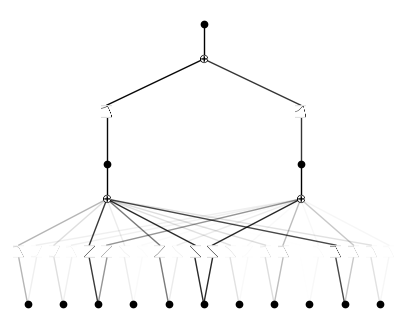

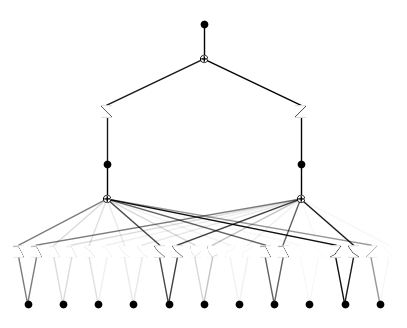

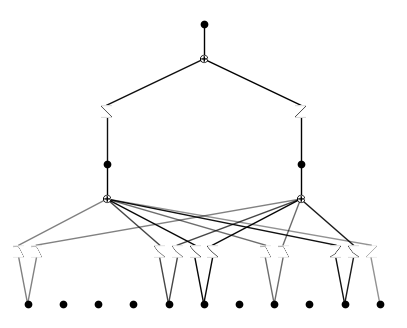

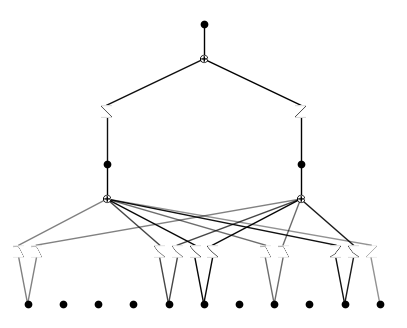

In [ ]:
model = KAN(width=[11, 2, 1], grid=3, k=1, seed=42, device=device)
model(dataset['train_input'])
model.plot()

model.fit(dataset, opt="Adam", steps=500, lr=0.01)
model.fit(dataset, opt="LBFGS", steps=300, lr=0.5, lamb=0.0)
model.plot()

model = model.prune(edge_th=5e-2)
model.fit(dataset, opt="LBFGS", steps=100, update_grid=False)
model.plot()

model = model.prune(edge_th=0.1)
model.fit(dataset, opt="LBFGS", steps=50, update_grid=False, lr=0.2)
model.plot()

In [ ]:
lib = ['x']
model.auto_symbolic(lib=lib)
formula = ex_round(model.symbolic_formula()[0][0], 4)
print("Символьная формула KAN:", formula)

with torch.no_grad():
    pred_test = model(X_test_t).cpu().numpy().flatten()
mse = np.mean((pred_test - y_test_sub)**2)
print(f"\nMSE на тесте: {mse:.6f}")

# Примеры с корректным восстановлением x и v
print("\nПримеры предсказаний vs истина:")
for i in np.random.choice(len(X_test_sub), 5, replace=False):
    x_scaled = X_test_sub[i, 0]
    v_scaled = X_test_sub[i, 1]
    # восстанавливаем исходные x и v
    orig_x = x_scaled * scaler.scale_[0] + scaler.mean_[0]
    orig_v = v_scaled * scaler.scale_[1] + scaler.mean_[1]
    # k, c, m – немасштабированные, берём как есть
    k_i = X_test_sub[i, 2]
    c_i = X_test_sub[i, 3]
    m_i = X_test_sub[i, 4]
    true_a = -(k_i/m_i)*orig_x - (c_i/m_i)*orig_v
    pred_a = pred_test[i]
    print(f"  x={orig_x:.2f}, v={orig_v:.2f}, k={k_i:.1f}, c={c_i:.1f}, m={m_i:.1f}: "
          f"истинное a={true_a:.3f}, предсказанное a={pred_a:.3f}")

fixing (0,0,0) with x, r2=0.7463169693946838, c=1
fixing (0,0,1) with x, r2=0.7383542060852051, c=1
fixing (0,1,0) with 0
fixing (0,1,1) with 0
fixing (0,2,0) with 0
fixing (0,2,1) with 0
fixing (0,3,0) with 0
fixing (0,3,1) with 0
fixing (0,4,0) with x, r2=0.9788171052932739, c=1
fixing (0,4,1) with x, r2=0.9780641198158264, c=1
fixing (0,5,0) with x, r2=0.9924454092979431, c=1
fixing (0,5,1) with x, r2=0.9923856258392334, c=1
fixing (0,6,0) with 0
fixing (0,6,1) with 0
fixing (0,7,0) with x, r2=0.674736738204956, c=1
fixing (0,7,1) with x, r2=0.6850820183753967, c=1
fixing (0,8,0) with 0
fixing (0,8,1) with 0
fixing (0,9,0) with x, r2=0.9330074191093445, c=1
fixing (0,9,1) with x, r2=0.907821536064148, c=1
fixing (0,10,0) with x, r2=1.0, c=1
fixing (0,10,1) with 0
fixing (1,0,0) with x, r2=0.9999919533729553, c=1
fixing (1,1,0) with x, r2=0.9999998211860657, c=1
saving model version 0.7
Символьная формула KAN: 0.003*x_1 - 0.999*x_10 - 0.9986*x_11 - 0.0042*x_5 - 0.0005*x_6 - 0.0028*x_